# **EBPP Final Project:** Hierarchical Bayesian Analysis of Player Impact

Case Study: Nikola Mirotić & FC Barcelona Basketball (2021/2022 Season)

In [24]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

# if error or warning about g++, on conda prompt:
# conda install -c conda-forge gxx_linux-64
# or
# conda install -c conda-forge m2w64-toolchain

In [2]:
# Set visualization parameters
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

# Fix random seed for reproducibility across MCMC samplers
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Data loading

In [3]:
df = pd.read_csv("data/Data_AllSeason.csv")

headers = ['play_id', 'point_guard', 'shooting_guard', 'small_forward', 'power_forward', 'center', 'points_difference',
           'play_type', 'good_shot', 'points', 'quarter', 'clutch', 'opponent', 'court', 'competition']
df.columns = headers

display(df)

,play_id,point_guard,shooting_guard,small_forward,power_forward,center,points_difference,play_type,good_shot,points,quarter,clutch,opponent,court,competition
0,1,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,0,2,1,2,1,0,Alba Berlin,Local,Eurolliga
1,2,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,2,2,1,3,1,0,Alba Berlin,Local,Eurolliga
2,3,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,2,1,0,Alba Berlin,Local,Eurolliga
3,4,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,3,1,0,Alba Berlin,Local,Eurolliga
4,5,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,8,4,1,0,1,0,Alba Berlin,Local,Eurolliga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3637,3638,Calathes,Higgins,Abrines,Mirotic,Sanli,7,4,1,2,4,0,Olympiacos,Neutral,F4
3638,3639,Calathes,Higgins,Abrines,Mirotic,Sanli,6,4,0,0,4,1,Olympiacos,Neutral,F4
3639,3640,Calathes,Higgins,Abrines,Mirotic,Sanli,5,2,1,2,4,1,Olympiacos,Neutral,F4
3640,3641,Calathes,Higgins,Abrines,Mirotic,Sanli,7,1,1,2,4,0,Olympiacos,Neutral,F4


We create a DataFrame only containing the plays where Mirotic was present on the court and another one for Davies.

In [4]:
# Construct indicators tracking presence of Mirotic vs baseline rotations
df['has_mirotic'] = df.apply(lambda row: int('Mirotic' in [row['point_guard'], row['shooting_guard'], 
                                                           row['small_forward'], row['power_forward'], 
                                                           row['center']]), axis=1)

print(f"Total processed dataset dimensions: {df.shape}")
print(f"Mirotić line-up sample entries: {df['has_mirotic'].sum()} plays.")

Total processed dataset dimensions: (3642, 16)
Mirotić line-up sample entries: 2132 plays.


In [5]:
df_mirotic = df[(df['has_mirotic'] == 1)]

# display(df_mirotic)

df_no_mirotic = df[(df['has_mirotic'] != 1)]

# display(df_no_mirotic)

In [6]:
# Encode categorical variables into indexing matrices for hierarchy mapping
# Define our target hierarchy categories: combination of court position and clutch time

df['strat_group'] = df['court'].astype(str) + "_" + df['clutch'].astype(str)
group_names = df['strat_group'].unique()
group_idx = pd.Categorical(df['strat_group']).codes
num_groups = len(group_names)

print(f"Extracted {num_groups} distinct operational environment strata indices:")
for idx, name in enumerate(group_names):
    print(f" Index {idx} -> Stratum Profile: {name} (N={np.sum(group_idx == idx)})")

Extracted 6 distinct operational environment strata indices:
 Index 0 -> Stratum Profile: Local_0 (N=1638)
 Index 1 -> Stratum Profile: Visitant_0 (N=193)
 Index 2 -> Stratum Profile: Visitant_1 (N=88)
 Index 3 -> Stratum Profile: Local_1 (N=94)
 Index 4 -> Stratum Profile: Neutral_1 (N=1515)
 Index 5 -> Stratum Profile: Neutral_0 (N=114)


In [7]:
df.head()

,play_id,point_guard,shooting_guard,small_forward,power_forward,center,points_difference,play_type,good_shot,points,quarter,clutch,opponent,court,competition,has_mirotic,strat_group
0,1,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,0,2,1,2,1,0,Alba Berlin,Local,Eurolliga,1,Local_0
1,2,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,2,2,1,3,1,0,Alba Berlin,Local,Eurolliga,1,Local_0
2,3,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,2,1,0,Alba Berlin,Local,Eurolliga,1,Local_0
3,4,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,3,1,0,Alba Berlin,Local,Eurolliga,1,Local_0
4,5,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,8,4,1,0,1,0,Alba Berlin,Local,Eurolliga,1,Local_0


# Non-Hierarchical Model Setup

## 1. Exploration of the `good_shot` column

In [8]:
# Case M)
case_m = df_mirotic['good_shot'] == 1

y_m = case_m.sum()
pi_hat_m = case_m.mean()

print("- Mirotic Case (good_shot = 1):")
print(f"Number of successes: {y_m} of {len(df_mirotic)}")
print(f"Sample proportion: {pi_hat_m}\n")


# Case D)
case_n = df_no_mirotic['good_shot'] == 1

y_n = case_n.sum()
pi_hat_n = case_n.mean()

print("- No Mirotic Case (good_shot = 1):")
print(f"Number of successes: {y_n} of {len(df_no_mirotic)}")
print(f"Sample proportion: {pi_hat_n}")

- Mirotic Case (good_shot = 1):
Number of successes: 1417 of 2132
Sample proportion: 0.6646341463414634

- No Mirotic Case (good_shot = 1):
Number of successes: 910 of 1510
Sample proportion: 0.6026490066225165


Now, we will check the proportion of good shots for the general dataset, so that later we can have an informed prior:

In [9]:
general_case = df['good_shot'] == 1

y_g = general_case.sum()
pi_hat_g = general_case.mean()

print("- General Case (good_shot = 1):")
print(f"Number of successes: {y_g} of {len(df)}")
print(f"Sample proportion: {pi_hat_g}\n")

- General Case (good_shot = 1):
Number of successes: 2327 of 3642
Sample proportion: 0.6389346512904998



## 2. Model choice

Observe that we only have two options (Success or Failure) for a fixed population in both cases, which clearly follows a Binomial distribution. Moreover, since our goal is to estimate a proportion and the Beta distribution is defined in the interval $[0 , 1]$, this makes the **Beta-Binomial** distribution a clear option.

Therefore, we have the following Bayesian model for each case:
- Mirotic Case:
$$
Y_M \mid \pi_M \sim \mathrm{Binomial}(2132,\pi_M),
\qquad
\pi_M \sim \mathrm{Beta}(\alpha,\beta).
$$

- No Mirotic Case:
$$
Y_N \mid \pi_N \sim \mathrm{Binomial}(1510,\pi_N),
\qquad
\pi_N \sim \mathrm{Beta}(\alpha,\beta).
$$
Where $Y_M$ and $Y_N$ are the observed number of successes, $\pi_M$ and $\pi_N$ are the unknown true population proportion, and $n_M=2132$ and $n_D=1510$ are the total sample size for the Mirotic and No Mirotic case respectively.

## 3. Prior definition

We chose an **Empirical Bayes** prior based on the team's overall success rate ($p = 0.63$) seen before. We set the prior strength to $N = 70$ (about 3-4% of our total data), which provides a stable baseline without overwhelming the actual evidence from the data. We apply the same prior to both cases to ensure a fair comparison.

**Prior distribution:**
$\pi \sim \operatorname{Beta}(\alpha, \beta)$

**Parameters:**
- $\alpha = 0.63 \times 70 = 44.1$
- $\beta = 0.37 \times 70 = 25.9$

By using $\operatorname{Beta}(44.1, 25.9)$ for both groups, any difference we find in the posterior distributions will be strictly due to Mirotic's specific impact on the game.

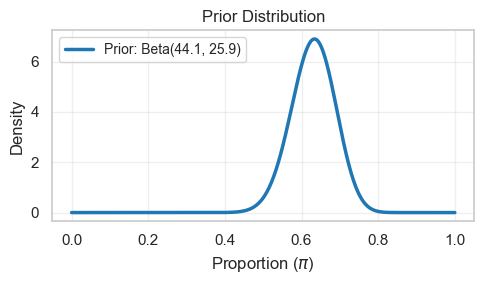

In [10]:
from scipy.stats import beta

x = np.linspace(0, 1, 500)

y_informative = beta.pdf(x, 44.1, 25.9)

plt.figure(figsize=(5, 3))

plt.plot(x, y_informative, label='Prior: Beta(44.1, 25.9)', color='#1f77b4', lw=2.5)

plt.title('Prior Distribution')
plt.xlabel('Proportion ($\pi$)')
plt.ylabel('Density')

plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Posterior Distribution

Since our priors are of the form $\pi \sim \operatorname{Beta}(\alpha,\beta)$ and the data follows a Binomial distribution $Y \sim \operatorname{Binomial}(n,\pi)$, we can obtain the posterior distributions analytically. This is done by adding the number of successes ($Y$) to $\alpha$ and the number of failures ($n - Y$) to $\beta$:

$$
\pi \mid Y \sim \operatorname{Beta}(\alpha + Y, \beta + n - Y)
$$

In our case, we use the previously defined informative prior $\operatorname{Beta}(44.1, 25.9)$. Based on the dataset:

- **Case M (Mirotic on court):**
    - $n_M = 2132$, $Y_M = 1417$
    - **Posterior:** $\operatorname{Beta}(44.1 + Y_M, 25.9 + n_M - Y_M)$

- **Case N (Mirotic off court):**
    - $n_N = 1510$, $Y_N = 910$
    - **Posterior:** $\operatorname{Beta}(44.1 + Y_N, 25.9 + n_N - Y_N)$

In the next cell, we visualize how the team's global prior is updated with the specific data from each case.

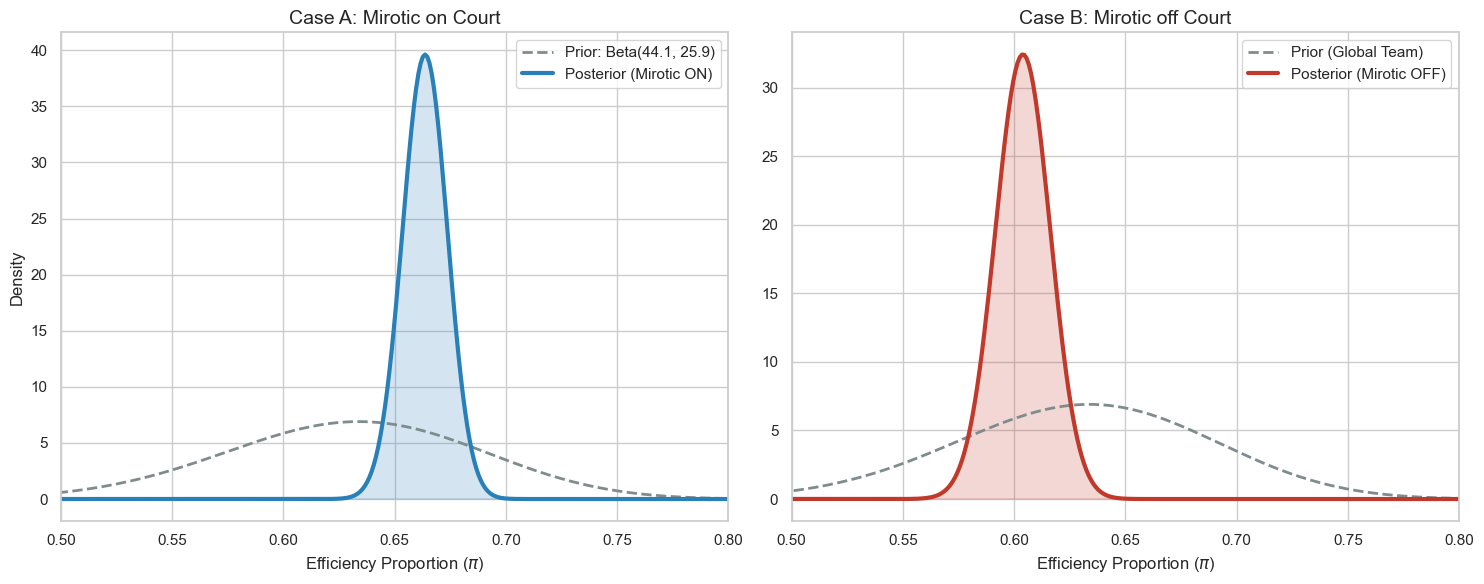

In [11]:
from scipy.stats import beta

# Case M: Mirotic on court
n_M = len(df_mirotic)
Y_M = df_mirotic['good_shot'].sum()

# Case N: No Mirotic on court
n_N = len(df_no_mirotic)
Y_N = df_no_mirotic['good_shot'].sum()

# Prior definition
alpha_prior, beta_prior = 44.1, 25.9

# Posterior calculation
alpha_post_M, beta_post_M = alpha_prior + Y_M, beta_prior + (n_M - Y_M)
alpha_post_N, beta_post_N = alpha_prior + Y_N, beta_prior + (n_N - Y_N)

# --- VISUALIZATION ---
x = np.linspace(0, 1, 1000)
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

c_prior = '#7f8c8d'
c_post_M = '#2980b9'
c_post_N = '#c0392b'

# SUBGRAPH 1: CASE M (Mirotic)
axs[0].plot(x, beta.pdf(x, alpha_prior, beta_prior), color=c_prior, lw=2, ls='--', label=f'Prior: Beta({alpha_prior}, {beta_prior})')
axs[0].plot(x, beta.pdf(x, alpha_post_M, beta_post_M), color=c_post_M, lw=3, label='Posterior (Mirotic ON)')
axs[0].fill_between(x, beta.pdf(x, alpha_post_M, beta_post_M), alpha=0.2, color=c_post_M)
axs[0].set_title('Case A: Mirotic on Court', fontsize=14)
axs[0].set_xlabel('Efficiency Proportion ($\pi$)')
axs[0].set_ylabel('Density')
axs[0].legend()

# SUBGRAPH 2: CASE N (No Mirotic)
axs[1].plot(x, beta.pdf(x, alpha_prior, beta_prior), color=c_prior, lw=2, ls='--', label='Prior (Global Team)')
axs[1].plot(x, beta.pdf(x, alpha_post_N, beta_post_N), color=c_post_N, lw=3, label='Posterior (Mirotic OFF)')
axs[1].fill_between(x, beta.pdf(x, alpha_post_N, beta_post_N), alpha=0.2, color=c_post_N)
axs[1].set_title('Case B: Mirotic off Court', fontsize=14)
axs[1].set_xlabel('Efficiency Proportion ($\pi$)')
axs[1].legend()

# Ajustar límites para ver mejor las campanas (alrededor del 63%)
plt.xlim(0.5, 0.8) 
plt.tight_layout()
plt.show()

In the result of the next cell, we can see the **posterior mean**, the **posterior standard deviation** and the **middle 95% posterior creadible interval** for each case:

In [12]:
from scipy.stats import beta

posteriors = {
    'Case M (Mirotic ON)': (alpha_post_M, beta_post_M),
    'Case N (Mirotic OFF)': (alpha_post_N, beta_post_N)
}

results = []
for name, (a, b) in posteriors.items():
    # Mean and variance calculation
    mean, var = beta.stats(a, b, moments='mv')
    # STD calculation
    std = var**0.5
    
    # 95% Credible Interval
    ci_lower = beta.ppf(0.025, a, b) 
    ci_upper = beta.ppf(0.975, a, b) 
    
    results.append({
        'Model Context': name,
        'Posterior Mean': f"{mean:.4f}",
        'Std Dev': f"{std:.4f}",
        '95% Credible Interval': f"[{ci_lower:.4f}, {ci_upper:.4f}]"
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

       Model Context Posterior Mean Std Dev 95% Credible Interval
 Case M (Mirotic ON)         0.6635  0.0101      [0.6437, 0.6831]
Case N (Mirotic OFF)         0.6039  0.0123      [0.5796, 0.6278]


We can see that we have around a 6% more chance to end the play with a good shot if we have Mirotic on the court. Moreover, we can see that there is no intersection between the credible intervals, so we can be highly confident that the team is better when Mirotic is playing.

## 5. Numerical Probability

To determine the probability that the team is more efficient with Mirotic on court, we perform a Monte Carlo simulation. We draw 100,000 random samples from both posterior distributions:
- $\pi_M \sim \operatorname{Beta}(44.1 + Y_M, 25.9 + n_M - Y_M)$
- $\pi_N \sim \operatorname{Beta}(44.1 + Y_N, 25.9 + n_N - Y_N)$

Then, we calculate the proportion of samples where $\pi_M > \pi_N$.

Probability of Mirotic improving the performance of the team: 99.9910%


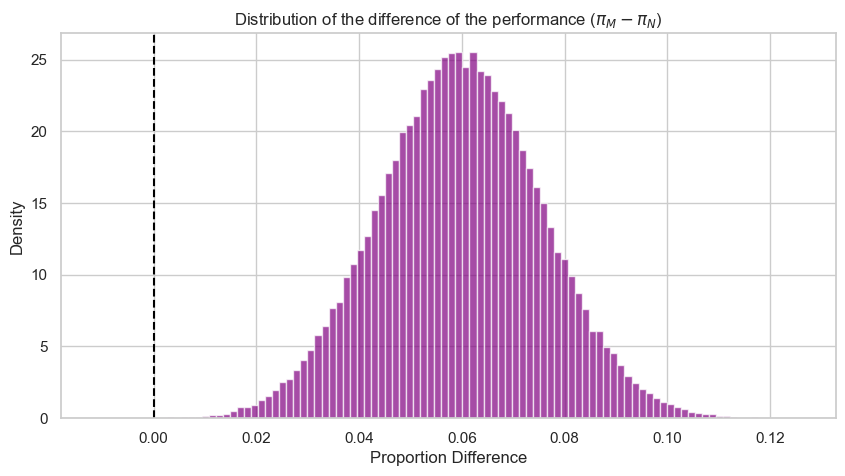

In [13]:
# Number of simulations
n_sims = 100000

# We generate samples from the posterior distributions
samples_M = np.random.beta(alpha_post_M, beta_post_M, n_sims)
samples_N = np.random.beta(alpha_post_N, beta_post_N, n_sims)

# We calculate the probability that having Mirotic on the court improves the efficiency compared to not having him
prob_M_better = np.mean(samples_M > samples_N)

print(f"Probability of Mirotic improving the performance of the team: {prob_M_better:.4%}")

plt.figure(figsize=(10, 5))
plt.hist(samples_M - samples_N, bins=100, color='purple', alpha=0.7, density=True)
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of the difference of the performance ($\pi_M - \pi_N$)')
plt.xlabel('Proportion Difference')
plt.ylabel('Density')
plt.show()

According to this Monte-Carlo simulation, we can be 99.995% sure that when we have Mirotic on court, we have more probability of taking a good shot at the end of a play.

# Hierarchical Model Setup

With the non-hierarchy model we were estimating efficiency using a group-wise flat model (no pooling), where we treat the case of “Mirotić on the court” and “Mirotić off the court” as if they were two completely isolated worlds. Therefore:

+ If we estimate each context separately (No Pooling): A player who plays only one minute in a given scenario and makes a three-pointer will appear to have 100% efficiency, distorting the data due to statistical noise.

+ If we combine all the data while ignoring context (Complete Pooling): You lose the ability to see whether Mirotić performs better under pressure or whether home-court effects influence team performance.

+ The Solution: The Hierarchical Model (Partial Pooling). A hierarchical model assumes that the effects of different contexts or players come from a shared higher-level distribution (a hyperdistribution).

## 1. Theoretical Framework of Hierarchical Logistic Regression

To capture how Nikola Mirotić impacts play outcomes across different situational strata (e.g., inside clutch moments or varying court advantages) without over-parameterizing, we implement a **Hierarchical Logistic Regression** utilizing **partial pooling**. 

In sports analytics, simple no-pooling models treat each operational environment independently, distorting estimates for strata with small sample sizes. Conversely, a flat complete-pooling model overlooks structural environmental differences. A hierarchical approach optimally balances these by allowing each operational stratum $j$ to have its own baseline intercept $\alpha_j$, while structurally pulling these estimates toward a shared global team mean $\mu_\alpha$.

The model specifies that the log-odds of a play succeeding ($\theta_i$) is a linear combination of the stratum intercept and the effect of Mirotić being on the floor:

$$
Y_i \sim \mathrm{Bernoulli}(\theta_i), \quad \forall i \in \{1, \dots, N\}
$$
$$
\operatorname{logit}(\theta_i) = \alpha_{\operatorname{group}_i} + \beta_{\operatorname{Mirotic}} \cdot \text{has\_mirotic}_i
$$

### Structural Random Intercepts (Non-Centered Parameterization)
To ensure reliable convergence and optimal sampling efficiency for the No-U-Turn Sampler (NUTS), we employ a **Non-Centered Parameterization**. This framework decouples the population hyperparameters from individual group parameters, smoothing out the geometry of the posterior distribution:

$$
\alpha_{\operatorname{offset}_j} \sim \mathcal{N}(0, 1) \quad \forall j \in \{1, \dots, J\}
$$
$$
\alpha_j = \mu_{\alpha} + \sigma_{\alpha} \cdot \alpha_{\operatorname{offset}_j}
$$

### Hyper-priors Hierarchy Definition
The priors for the global hyper-parameters are configured as follows:
$$
\mu_{\alpha} \sim \mathcal{N}(0, 2^2), \qquad \sigma_{\alpha} \sim \mathrm{HalfNormal}(1.5^2), \qquad \beta_{\operatorname{Mirotic}} \sim \mathcal{N}(0, 2^2)
$$

In [14]:
# Extract indices and dimensions for the PyMC hierarchical structure
y_obs = df['good_shot'].values
has_mirotic_idx = df['has_mirotic'].values
group_mapping = group_idx
num_groups = len(group_names)

print(f"Target Observations (Plays): {len(y_obs)}")
print(f"Hierarchical Stratum Groups Available: {num_groups} {list(group_names)}")

Target Observations (Plays): 3642
Hierarchical Stratum Groups Available: 6 ['Local_0', 'Visitant_0', 'Visitant_1', 'Local_1', 'Neutral_1', 'Neutral_0']


## 2. Model Choice & Compilation in PyMC

In [15]:
# Pass coordinates definition into pm.Model context to support dims="groups"
with pm.Model(coords={"groups": group_names}) as hierarchical_model:
    # Hyper-priors for the group intercepts
    mu_a = pm.Normal('mu_a', mu=0, sigma=2.0)
    sigma_a = pm.HalfNormal('sigma_a', sigma=1.5)
    
    # Non-centered random effects offsets
    a_offset = pm.Normal('a_offset', mu=0, sigma=1.0, shape=num_groups)
    
    # Deterministic transformation to recover the individual group intercepts (alpha_j)
    alpha = pm.Deterministic('alpha', mu_a + sigma_a * a_offset, dims="groups")
    
    # Fixed effect coefficient for Mirotic's presence on court
    beta_mirotic = pm.Normal('beta_mirotic', mu=0, sigma=2.0)
    
    # Linear predictor mapping using advanced indexing for strata tracking
    logit_theta = alpha[group_mapping] + beta_mirotic * has_mirotic_idx
    
    # Likelihood function
    y_likelihood = pm.Bernoulli('y_obs', logit_p=logit_theta, observed=y_obs)

## 3. Prior Definition & Posterior MCMC Sampling

In [17]:
# Sample the posterior distribution using the NUTS sampler
with hierarchical_model:
    idata_hierarchical = pm.sample(
        draws=2000, 
        tune=1000, 
        chains=4, 
        random_seed=RANDOM_SEED, 
        return_inferencedata=True
    )
    # Compute log-likelihood values to facilitate WAIC/LOO cross-validation comparisons
    pm.compute_log_likelihood(idata_hierarchical)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_a, sigma_a, a_offset, beta_mirotic]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 82 seconds.
There were 220 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

## 4. Posterior Distribution Visualizations and Summaries

In [18]:
# Summary metrics for checking convergence parameters (R-hat, Ess) and parameters behavior
summary_hier = az.summary(idata_hierarchical, var_names=['mu_a', 'sigma_a', 'beta_mirotic', 'alpha'])
display(summary_hier)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,0.421,0.207,-0.004,0.809,0.027,0.044,149.0,39.0,1.02
sigma_a,0.336,0.202,0.002,0.716,0.016,0.016,252.0,78.0,1.02
beta_mirotic,0.274,0.071,0.139,0.402,0.002,0.001,1545.0,3330.0,1.00
alpha[Local_0],0.471,0.062,0.356,0.587,0.001,0.001,3469.0,4550.0,1.00
alpha[Visitant_0],0.613,0.161,0.323,0.911,0.003,0.002,2807.0,4096.0,1.00
alpha[Visitant_1],0.554,0.200,0.190,0.943,0.007,0.005,934.0,673.0,1.01
alpha[Local_1],0.436,0.186,0.100,0.806,0.004,0.003,2100.0,1871.0,1.00
alpha[Neutral_1],0.350,0.066,0.216,0.466,0.001,0.001,3171.0,2261.0,1.00
alpha[Neutral_0],0.018,0.216,-0.355,0.436,0.006,0.003,1212.0,2781.0,1.01


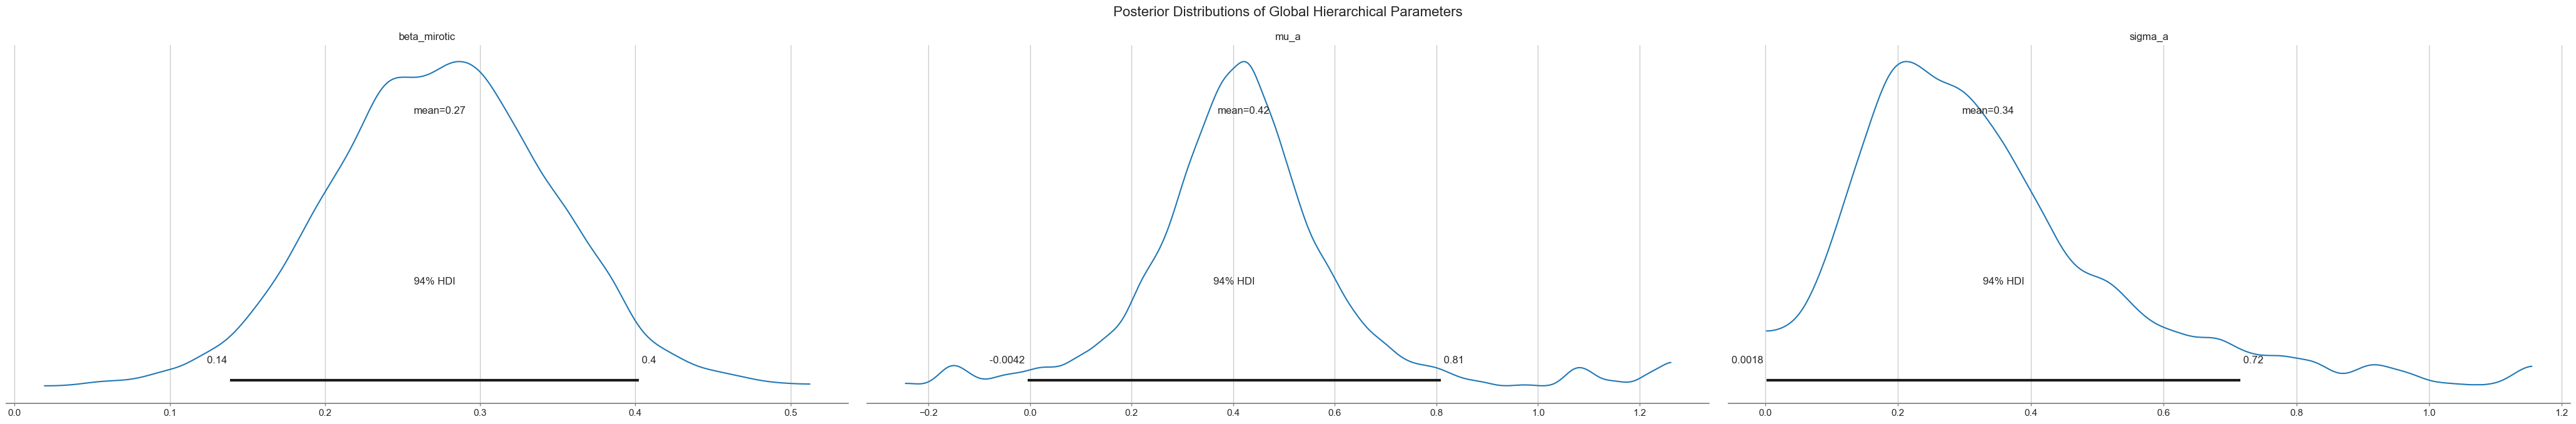

In [19]:
# Plot posterior densities for the core parameters to verify model stability
az.plot_posterior(idata_hierarchical, var_names=['beta_mirotic', 'mu_a', 'sigma_a'], color='#1f77b4')
plt.suptitle('Posterior Distributions of Global Hierarchical Parameters', fontsize=16)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

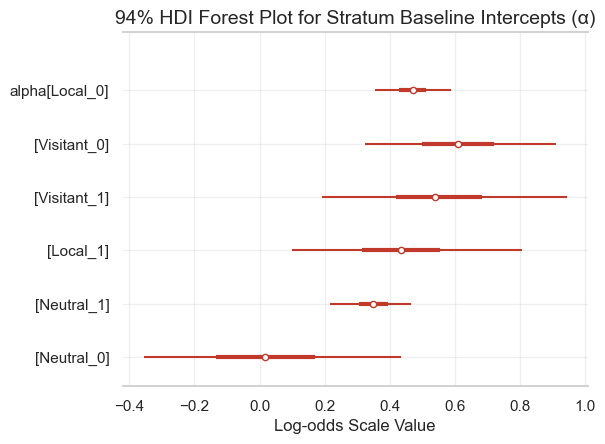

In [20]:
# Plot forest distributions comparison across extracted strata baseline capabilities
plt.figure(figsize=(10, 5))
az.plot_forest(idata_hierarchical, var_names=['alpha'], combined=True, colors=['#c0392b'])
plt.title('94% HDI Forest Plot for Stratum Baseline Intercepts (α)', fontsize=14)
plt.xlabel('Log-odds Scale Value')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Model Comparison: Flat Model vs. Hierarchical Model

To systematically evaluate whether the hierarchical model outperforms a non-hierarchical approach, we implement a flat comparison baseline model utilizing the exact same variables and parameters inside a unified logit structure. Then, we execute a comparative evaluation using **WAIC** and **LOO-CV** criteria.

In [21]:
# Compile reference Flat Model for comprehensive validation structure
with pm.Model() as flat_logistic_model:
    alpha_flat = pm.Normal('alpha_flat', mu=0, sigma=2.0, shape=num_groups)
    beta_flat = pm.Normal('beta_flat', mu=0, sigma=2.0)
    
    logit_theta_flat = alpha_flat[group_mapping] + beta_flat * has_mirotic_idx
    y_flat_likelihood = pm.Bernoulli('y_obs', logit_p=logit_theta_flat, observed=y_obs)
    
    idata_flat = pm.sample(draws=2000, tune=1000, chains=4, random_seed=RANDOM_SEED, return_inferencedata=True)
    pm.compute_log_likelihood(idata_flat)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_flat, beta_flat]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 43 seconds.


Output()

In [22]:
# Execute formal information criteria comparison via ArviZ 
comparison_dict = {
    "Hierarchical Model (Partial Pooling)": idata_hierarchical,
    "Flat Model (No/Complete Pooling)": idata_flat
}

print("=== WAIC MODEL COMPARISON ===")
waic_comparison = az.compare(comparison_dict, ic="waic")
display(waic_comparison)

print("\n=== LOO-CV MODEL COMPARISON ===")
loo_comparison = az.compare(comparison_dict, ic="loo")
display(loo_comparison)

=== WAIC MODEL COMPARISON ===


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Flat Model (No/Complete Pooling),0,-2372.924665,7.012176,0.000000,0.692129,17.393735,0.000000,False,log
Hierarchical Model (Partial Pooling),1,-2373.257660,6.498046,0.332994,0.307871,17.147729,1.316454,False,log



=== LOO-CV MODEL COMPARISON ===


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Flat Model (No/Complete Pooling),0,-2372.930372,7.017882,0.000000,0.691904,17.393813,0.000000,False,log
Hierarchical Model (Partial Pooling),1,-2373.262977,6.503363,0.332605,0.308096,17.147804,1.316454,False,log


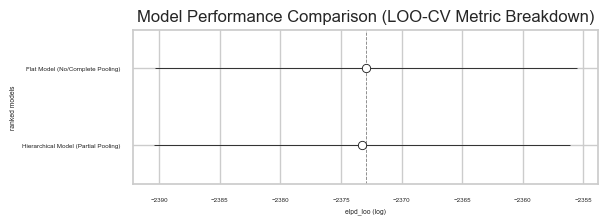

In [23]:
# Visualize comparison plot showing model weights and expected log pointwise predictive density (elpd)
az.plot_compare(loo_comparison, backend="matplotlib")
plt.title("Model Performance Comparison (LOO-CV Metric Breakdown)")
plt.show()